# Hafta 11 - Apriori ile Basit Sepet Analizi

Bu notebook, kendi olusturdugumuz kucuk bir market sepeti ornek seti uzerinde Apriori algoritmasini adim adim anlatir.

Hedefler:
- Sepet verisini kendi ornek setimizle tanimlamak,
- Transaction verisini one-hot formatina cevirmek,
- Apriori ile sik itemset'leri bulmak,
- Confidence ve lift ile basit kurallar cikarmak,
- Sonuclari kisa bir yorumla degerlendirmek.

Not:
- Bu notebook dis veri seti kullanmaz.
- Apriori mantigi daha kolay anlasilsin diye kucuk ve elle okunabilir bir veri seti secildi.

In [ ]:
from collections import Counter
from itertools import combinations

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", palette="Set2")

transactions = [
    ["bread", "milk", "butter"],
    ["bread", "diapers", "beer", "eggs"],
    ["milk", "diapers", "beer", "cola"],
    ["bread", "milk", "diapers", "beer"],
    ["bread", "milk", "diapers", "cola"],
    ["milk", "bread", "butter", "jam"],
    ["bread", "butter"],
    ["milk", "diapers", "beer", "bread"],
]

items = sorted({item for basket in transactions for item in basket})
print(f"Transaction sayisi: {len(transactions)}")
print(f"Urun sayisi: {len(items)}")
print("Urunler:", items)

Transaction sayisi: 8
Urun sayisi: 8
Urunler: ['beer', 'bread', 'butter', 'cola', 'diapers', 'eggs', 'jam', 'milk']


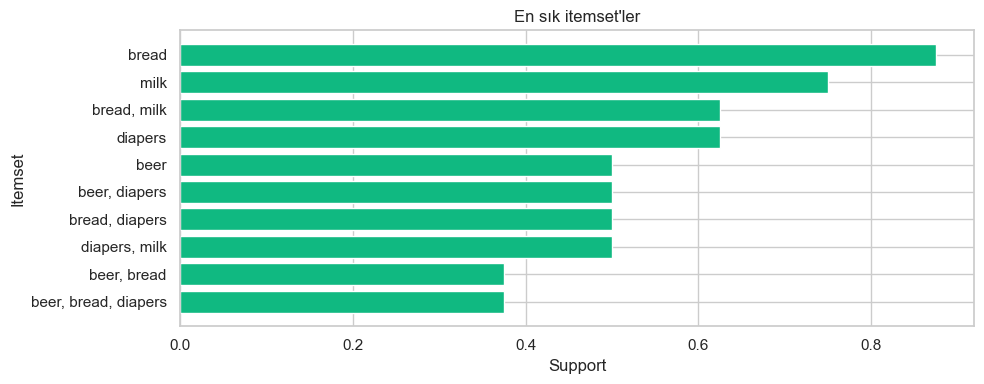

En guclu kural:
beer -> diapers | support=0.50, confidence=1.00, lift=1.60


In [5]:
top_itemsets = frequent_df.copy()
if not top_itemsets.empty:
    top_itemsets = top_itemsets.head(10)
    plt.figure(figsize=(10, 4))
    plt.barh(top_itemsets["itemset"], top_itemsets["support"], color="#10b981")
    plt.gca().invert_yaxis()
    plt.title("En sık itemset'ler")
    plt.xlabel("Support")
    plt.ylabel("Itemset")
    plt.tight_layout()
    plt.show()

print("En guclu kural:")
if not rules_df.empty:
    best_rule = rules_df.iloc[0]
    print(
        f"{best_rule['antecedent']} -> {best_rule['consequent']} | "
        f"support={best_rule['support']:.2f}, confidence={best_rule['confidence']:.2f}, lift={best_rule['lift']:.2f}"
    )
else:
    print("Kurallar icin yeterli esik bulunamadi.")

## 4. Goruntuleme

En sık itemset'leri bir cizimle gorelim ve Apriori sonuclarini kisa ozetleyelim.

In [4]:
def build_support_lookup(frequent_itemsets):
    return {itemset: support for itemset, support in frequent_itemsets}


def generate_rules(frequent_itemsets, min_confidence=0.6):
    support_lookup = build_support_lookup(frequent_itemsets)
    rules = []

    for itemset, itemset_support in frequent_itemsets:
        if len(itemset) < 2:
            continue

        items_in_set = sorted(itemset)
        for r in range(1, len(items_in_set)):
            for antecedent_items in combinations(items_in_set, r):
                antecedent = frozenset(antecedent_items)
                consequent = itemset - antecedent
                antecedent_support = support_lookup.get(antecedent)
                consequent_support = support_lookup.get(consequent)

                if not antecedent_support or not consequent_support:
                    continue

                confidence = itemset_support / antecedent_support
                lift = confidence / consequent_support
                if confidence >= min_confidence:
                    rules.append(
                        {
                            "antecedent": ", ".join(sorted(antecedent)),
                            "consequent": ", ".join(sorted(consequent)),
                            "support": itemset_support,
                            "confidence": confidence,
                            "lift": lift,
                        }
                    )

    if not rules:
        return pd.DataFrame(columns=["antecedent", "consequent", "support", "confidence", "lift"])

    return pd.DataFrame(rules).sort_values(["confidence", "lift", "support"], ascending=False)


rules_df = generate_rules(frequent_itemsets, min_confidence=0.6)
print(rules_df.to_string(index=False))

    antecedent     consequent  support  confidence     lift
          beer        diapers    0.500    1.000000 1.600000
   beer, bread        diapers    0.375    1.000000 1.600000
    beer, milk        diapers    0.375    1.000000 1.600000
        butter          bread    0.375    1.000000 1.142857
          milk          bread    0.625    0.833333 0.952381
       diapers           beer    0.500    0.800000 1.600000
       diapers           milk    0.500    0.800000 1.066667
       diapers          bread    0.500    0.800000 0.914286
          beer bread, diapers    0.375    0.750000 1.500000
bread, diapers           beer    0.375    0.750000 1.500000
          beer  diapers, milk    0.375    0.750000 1.500000
 diapers, milk           beer    0.375    0.750000 1.500000
          beer           milk    0.375    0.750000 1.000000
 beer, diapers           milk    0.375    0.750000 1.000000
bread, diapers           milk    0.375    0.750000 1.000000
          beer          bread    0.375  

## 3. Kural uretimi

Sik itemset'lerden `confidence` ve `lift` hesaplayarak basit bir "eger A varsa B de olma ihtimali" yorumuna ulasabiliriz.

In [3]:
def support_for_itemset(transactions_list, itemset):
    itemset = frozenset(itemset)
    count = sum(itemset.issubset(set(basket)) for basket in transactions_list)
    return count / len(transactions_list)


def apriori(transactions_list, min_support=0.3):
    transaction_sets = [set(basket) for basket in transactions_list]
    unique_items = sorted({item for basket in transaction_sets for item in basket})

    frequent_itemsets = []
    current_level = []

    # 1-itemset'ler
    for item in unique_items:
        itemset = frozenset([item])
        support = support_for_itemset(transaction_sets, itemset)
        if support >= min_support:
            current_level.append(itemset)
            frequent_itemsets.append((itemset, support))

    k = 2
    while current_level:
        candidates = set()
        for left, right in combinations(current_level, 2):
            candidate = left | right
            if len(candidate) == k:
                candidates.add(candidate)

        next_level = []
        for candidate in sorted(candidates, key=lambda x: sorted(x)):
            support = support_for_itemset(transaction_sets, candidate)
            if support >= min_support:
                next_level.append(candidate)
                frequent_itemsets.append((candidate, support))

        current_level = next_level
        k += 1

    return frequent_itemsets


frequent_itemsets = apriori(transactions, min_support=0.3)
frequent_df = pd.DataFrame(
    [{"itemset": ", ".join(sorted(itemset)), "support": support} for itemset, support in frequent_itemsets]
).sort_values(["support", "itemset"], ascending=[False, True])

print(frequent_df.to_string(index=False))

             itemset  support
               bread    0.875
                milk    0.750
         bread, milk    0.625
             diapers    0.625
                beer    0.500
       beer, diapers    0.500
      bread, diapers    0.500
       diapers, milk    0.500
         beer, bread    0.375
beer, bread, diapers    0.375
 beer, diapers, milk    0.375
          beer, milk    0.375
       bread, butter    0.375
bread, diapers, milk    0.375
              butter    0.375


## 2. Apriori mantigi

Apriori iki temel fikir uzerine kurulur:
- Bir itemset sık degilse onun ust kumesi de sık degildir.
- Bu sayede aday sayisi agresif sekilde azaltilir.

Aşağıdaki hücrede basit bir Apriori uygulamasi kuruyoruz.

In [2]:
basket_df = pd.DataFrame(
    [{item: (item in basket) for item in items} for basket in transactions],
    dtype=bool,
)

basket_df.index = [f"T{i+1}" for i in range(len(basket_df))]
print(basket_df.astype(int))

    beer  bread  butter  cola  diapers  eggs  jam  milk
T1     0      1       1     0        0     0    0     1
T2     1      1       0     0        1     1    0     0
T3     1      0       0     1        1     0    0     1
T4     1      1       0     0        1     0    0     1
T5     0      1       0     1        1     0    0     1
T6     0      1       1     0        0     0    1     1
T7     0      1       1     0        0     0    0     0
T8     1      1       0     0        1     0    0     1


## 1. Transaction verisini one-hot formata cevirme

Apriori, her sepet icinde urunun var olup olmadigini gormek ister. Bu nedenle transaction listesini satirlarda sepet, sutunlarda urun olacak sekilde boolean bir tabloya ceviriyoruz.